# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w724_s10"
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / "reconstruction_analysis"

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (16): ['AE_12dim_0005', 'AE_15dim_0003', 'AE_20dim_0004', 'AE_3dim_0003', 'AE_70dim_0005', 'linearAE_12dim_0001_biasFalse', 'linearAE_12dim_0003', 'linearAE_15dim_0001_biasFalse', 'linearAE_15dim_0002', 'linearAE_20dim_0001', 'linearAE_20dim_0001_biasFalse', 'linearAE_3dim_0001', 'linearAE_3dim_0001_biasFalse', 'linearAE_70dim_0001', 'linearAE_70dim_0001_biasFalse', 'PCA']


In [3]:
import re


def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / "reconstruction_errors.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = None
                    if "n_components" in row and pd.notna(row["n_components"]):
                        k = int(row["n_components"])

                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    err_block = None
                    row_errs = row.get("reconstruction_errors")
                    if isinstance(row_errs, dict):
                        err_block = row_errs
                    else:
                        err_block = {}
                        if "MSE_mean" in row and pd.notna(row["MSE_mean"]):
                            err_block.setdefault("MSE", {})["mean"] = float(row["MSE_mean"])
                        if "MAE_mean" in row and pd.notna(row["MAE_mean"]):
                            err_block.setdefault("MAE", {})["mean"] = float(row["MAE_mean"])
                        if "Frobenius_mean" in row and pd.notna(row["Frobenius_mean"]):
                            err_block.setdefault("Frobenius", {})["mean"] = float(row["Frobenius_mean"])
                        if not err_block:
                            err_block = None

                    if err_block is not None:
                        record.update(flatten_metric_stats(err_block, prefix="err_"))
                    else:
                        print(f"Missing reconstruction_errors block for {model_name}")

                    if "mean_explained_variance" in row and pd.notna(row["mean_explained_variance"]):
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"

    k = None
    dim_match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if dim_match:
        k = int(dim_match.group(1))
    else:
        after_method = re.search(r"^[^_]+_(\d+)(?:_|$)", model_name)
        if after_method:
            k = int(after_method.group(1))
        else:
            any_num = re.search(r"(\d+)", model_name)
            if any_num:
                k = int(any_num.group(1))

    return method, k


def extract_run_id(model_name: str, k):
    nums = [int(x) for x in re.findall(r"(\d+)", model_name)]
    if not nums:
        return None
    if k is None:
        return nums[-1]
    for value in reversed(nums):
        if value != k:
            return value
    return None


method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE"]
method_rank = {m: i for i, m in enumerate(method_order)}


def model_sort_key(model_name: str):
    method, k = parse_model_name(model_name)
    run_id = extract_run_id(model_name, k)
    method_pos = method_rank.get(method, len(method_order))
    k_pos = k if k is not None else float("inf")
    run_pos = run_id if run_id is not None else float("inf")
    return (method_pos, k_pos, run_pos, model_name.lower())


def sort_by_method_k(df: pd.DataFrame):
    ordered_index = sorted(df.index, key=model_sort_key)
    return df.loc[ordered_index]


print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df = sort_by_method_k(stats_df)
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_12dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_15dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_20dim_0004'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_3dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_70dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/linearAE_12dim_0001_biasFalse'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelatio

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max,pca_mean_explained_variance,pca_selected_k
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PCA_1,0.006292,0.002880,0.002433,0.005403,0.011211,0.047101,0.010889,0.029908,0.042225,0.063003,27.960027,6.622250,17.856901,26.609984,38.328902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.375410,1.0
PCA_3,0.002390,0.000646,0.001426,0.002513,0.003307,0.028878,0.004056,0.021577,0.029317,0.034704,17.531011,2.444237,13.668172,18.148518,20.817455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.454599,3.0
PCA_12,0.001128,0.000293,0.000728,0.001149,0.001717,0.017682,0.002145,0.014366,0.017729,0.021419,12.054793,1.591221,9.765436,12.270057,14.999221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.553868,12.0
PCA_15,0.001019,0.000273,0.000613,0.001046,0.001593,0.016734,0.002105,0.013727,0.016730,0.020699,11.455089,1.555102,8.960628,11.705690,14.446600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.571743,15.0
PCA_20,0.000886,0.000245,0.000491,0.000915,0.001422,0.015610,0.002046,0.012039,0.015648,0.019584,10.675263,1.497861,8.019518,10.949547,13.651848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.597312,20.0
PCA_50,0.000467,0.000149,0.000215,0.000487,0.000826,0.011734,0.001817,0.008121,0.012051,0.015610,7.727615,1.250972,5.312910,7.989133,10.404682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.707645,50.0
PCA_70,0.000321,0.000109,0.000139,0.000331,0.000593,0.009977,0.001662,0.006705,0.010241,0.013608,6.391057,1.102687,4.260952,6.583666,8.817748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.761179,70.0
PCA_100,0.000185,0.000068,0.000074,0.000188,0.000362,0.007871,0.001427,0.005057,0.008027,0.011104,4.849156,0.900557,3.104524,4.961096,6.890051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.823930,100.0
PCA_150,0.000073,0.000030,0.000026,0.000072,0.000154,0.005200,0.001056,0.003176,0.005260,0.007693,3.030087,0.619568,1.848527,3.070042,4.485322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,N

In [4]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

print("Reconstruction error means (lower is better):")
display(sort_by_method_k(err_means))

print("Reconstruction error std:")
display(sort_by_method_k(err_stds))

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)
err_ranks = err_ranks.sort_values("avg_rank")

print("Reconstruction error rank (lower is better):")
display(sort_by_method_k(err_ranks))

Reconstruction error means (lower is better):


,MSE,MAE,Frobenius
model,,,
PCA_1,0.006292,0.047101,27.960027
PCA_3,0.002390,0.028878,17.531011
PCA_12,0.001128,0.017682,12.054793
PCA_15,0.001019,0.016734,11.455089
PCA_20,0.000886,0.015610,10.675263
PCA_50,0.000467,0.011734,7.727615
PCA_70,0.000321,0.009977,6.391057
PCA_100,0.000185,0.007871,4.849156
PCA_150,0.000073,0.005200,3.030087


Reconstruction error std:


,MSE,MAE,Frobenius
model,,,
PCA_1,0.002880,0.010889,6.622250
PCA_3,0.000646,0.004056,2.444237
PCA_12,0.000293,0.002145,1.591221
PCA_15,0.000273,0.002105,1.555102
PCA_20,0.000245,0.002046,1.497861
PCA_50,0.000149,0.001817,1.250972
PCA_70,0.000109,0.001662,1.102687
PCA_100,0.000068,0.001427,0.900557
PCA_150,0.000030,0.001056,0.619568


Reconstruction error rank (lower is better):


,MSE,MAE,Frobenius,avg_rank
model,,,,
PCA_1,23.0,23.0,23.0,23.000000
PCA_3,20.0,20.0,20.0,20.000000
PCA_12,19.0,19.0,19.0,19.000000
PCA_15,18.0,18.0,18.0,18.000000
PCA_20,17.0,15.0,17.0,16.333333
PCA_50,14.0,7.0,14.0,11.666667
PCA_70,8.0,4.0,9.0,7.000000
PCA_100,3.0,3.0,3.0,3.000000
PCA_150,2.0,2.0,2.0,2.000000


In [5]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)

print("MST comparison means:")
display(sort_by_method_k(mst_means))

higher_better = {"edge_overlap_pct", "edge_jaccard_pct", "betweenness_topk_overlap_pct"}
lower_better = {"degree_l1", "avg_path_len_diff", "avg_path_len_unweighted_diff"}


def rank_mst(df: pd.DataFrame):
    ranks = pd.DataFrame(index=df.index)
    for metric in df.columns:
        if metric in higher_better:
            ranks[metric] = df[metric].rank(ascending=False)
        else:
            ranks[metric] = df[metric].rank(ascending=True)
    ranks["avg_rank"] = ranks.mean(axis=1)
    return ranks.sort_values("avg_rank")


mst_ranks = rank_mst(mst_means)
print("MST rank (higher overlap is better, lower diffs are better):")
display(sort_by_method_k(mst_ranks))

MST comparison means:


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct
model,,,,,,
PCA_1,NaN,NaN,NaN,NaN,NaN,NaN
PCA_3,NaN,NaN,NaN,NaN,NaN,NaN
PCA_12,NaN,NaN,NaN,NaN,NaN,NaN
PCA_15,NaN,NaN,NaN,NaN,NaN,NaN
PCA_20,NaN,NaN,NaN,NaN,NaN,NaN
PCA_50,NaN,NaN,NaN,NaN,NaN,NaN
PCA_70,NaN,NaN,NaN,NaN,NaN,NaN
PCA_100,NaN,NaN,NaN,NaN,NaN,NaN
PCA_150,NaN,NaN,NaN,NaN,NaN,NaN


MST rank (higher overlap is better, lower diffs are better):


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct,avg_rank
model,,,,,,,
PCA_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA_150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
summary = pd.DataFrame(index=stats_df.index)
summary["err_score"] = err_ranks["avg_rank"]
summary["mst_score"] = mst_ranks["avg_rank"]
summary["combined_score"] = summary.mean(axis=1)
summary = summary.sort_values("combined_score")

print("Combined score (lower is better):")
display(sort_by_method_k(summary))

Combined score (lower is better):


,err_score,mst_score,combined_score
model,,,
PCA_1,23.000000,NaN,23.000000
PCA_3,20.000000,NaN,20.000000
PCA_12,19.000000,NaN,19.000000
PCA_15,18.000000,NaN,18.000000
PCA_20,16.333333,NaN,16.333333
PCA_50,11.666667,NaN,11.666667
PCA_70,7.000000,NaN,7.000000
PCA_100,3.000000,NaN,3.000000
PCA_150,2.000000,NaN,2.000000


# K-based comparison plots
Build plots for error metrics across K and methods.

In [7]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    if method == "linearAE" and "biasfalse" in model_name.lower():
        method = "linearAE_biasFalse"

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

pca_sweep_path = project_root / "results" / f"{DATASET_NAME}" / "reconstruction_analysis" / "PCA" / "reconstruction_errors.json"
if pca_sweep_path.exists():
    pca_payload = load_json(pca_sweep_path)
    if isinstance(pca_payload, dict) and "sweep" in pca_payload:
        pca_rows = pca_payload["sweep"]
    elif isinstance(pca_payload, list):
        pca_rows = pca_payload
    else:
        pca_rows = []
        print(f"Unexpected PCA sweep format in {pca_sweep_path.name}")

    pca_df = pd.DataFrame(pca_rows)
    if not pca_df.empty:
        if "reconstruction_errors" in pca_df.columns:
            def extract_metric_mean(errs, metric_name):
                if isinstance(errs, dict):
                    metric_block = errs.get(metric_name, {})
                    if isinstance(metric_block, dict):
                        return metric_block.get("mean")
                return None

            for metric in available_err_metrics:
                metric_col = f"{metric}_mean"
                if metric_col not in pca_df.columns:
                    pca_df[metric_col] = pca_df["reconstruction_errors"].apply(
                        lambda v, m=metric: extract_metric_mean(v, m)
)

        pca_long_parts = []
        for metric in available_err_metrics:
            metric_col = f"{metric}_mean"
            if metric_col not in pca_df.columns:
                continue
            part = pca_df[["n_components", metric_col]].rename(
                columns={"n_components": "K", metric_col: "error"}
)
            part["metric"] = metric
            part["method"] = "PCA"
            pca_long_parts.append(part)
        if pca_long_parts:
            pca_long = pd.concat(pca_long_parts, ignore_index=True)
            pca_long["K"] = pca_long["K"].astype(int)
            err_long = pd.concat([err_long, pca_long], ignore_index=True)
            err_long = err_long.drop_duplicates(
                subset=["method", "K", "metric"],
                keep="last",
)
        else:
            print(f"No matching PCA metrics found in {pca_sweep_path.name}")
    else:
        print(f"PCA sweep file is empty: {pca_sweep_path}")
else:
    print(f"PCA sweep file not found: {pca_sweep_path}")

method_order = ["PCA", "linearAE_biasFalse", "linearAE", "AE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {
    "PCA": "PCA",
    "linearAE_biasFalse": "LinearAE (biasFalse)",
    "linearAE": "LinearAE",
    "AE": "AE",
}
method_colors = {
    "PCA": "tab:blue",
    "linearAE_biasFalse": "tab:olive",
    "linearAE": "tab:green",
    "AE": "tab:red",
}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE_biasFalse', 'linearAE', 'AE']
K values: [np.int64(1), np.int64(3), np.int64(12), np.int64(15), np.int64(20), np.int64(50), np.int64(70), np.int64(100), np.int64(150), np.int64(200)]


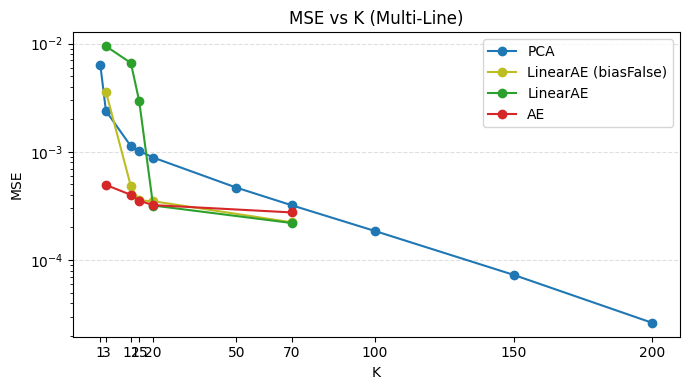

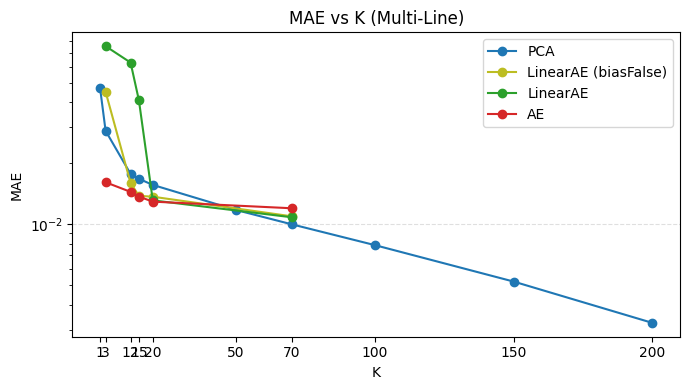

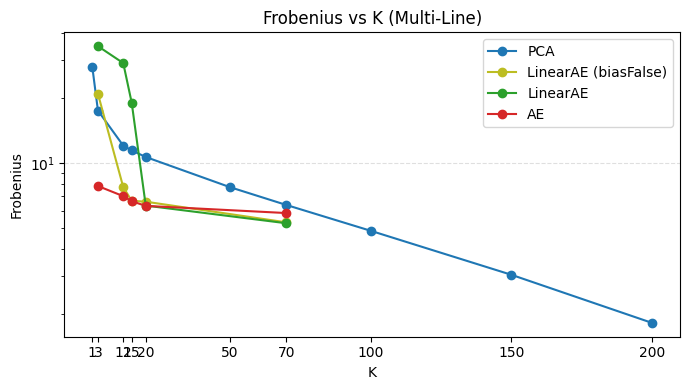

In [8]:
for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

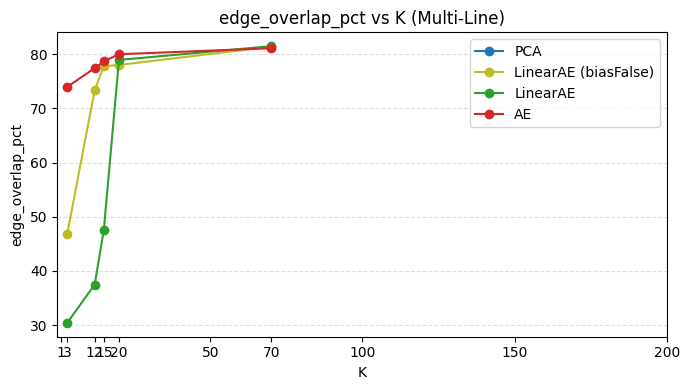

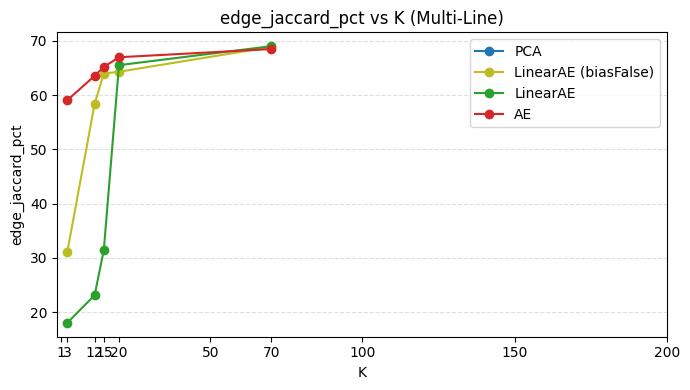

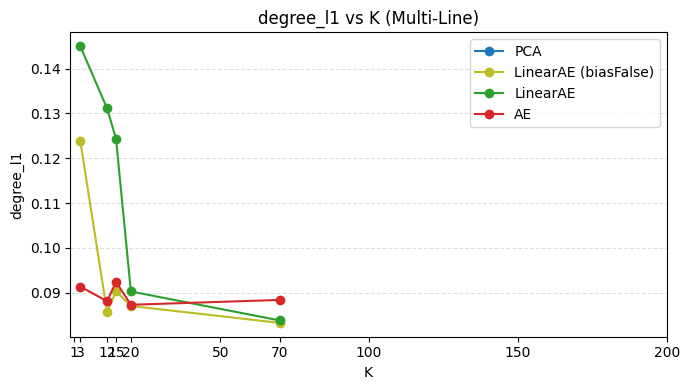

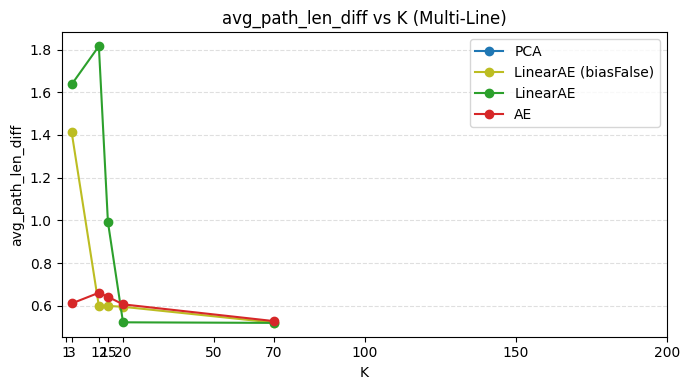

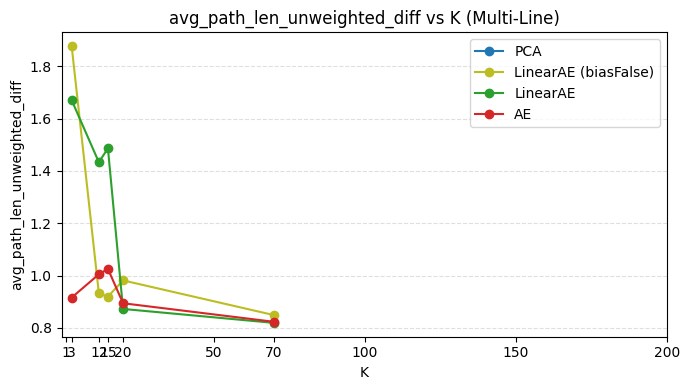

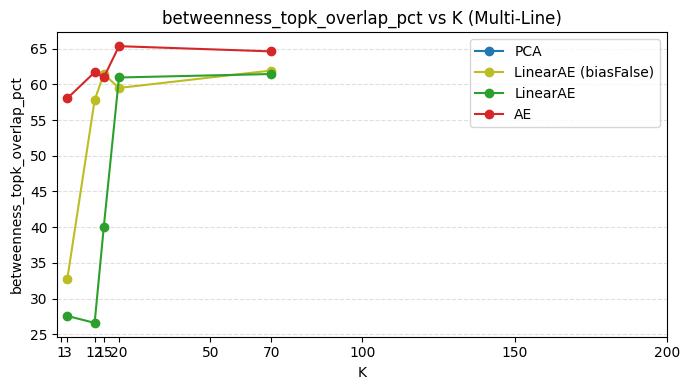

In [9]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()